<a href="https://colab.research.google.com/github/AR-Ashik-9997/Phitron-practice-problem/blob/main/eid_vacation_practice_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Eid Vacation Practice Challenge

## IMPORT LIBRARIES

In [ ]:
# Import required libraries here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler,OneHotEncoder

# Q1 — THE INCOME TRAP

## Load Dataset

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

df_adult = pd.read_csv(url, header=None, skipinitialspace=True)

df_adult.columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]


In [ ]:
df_adult

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


## THEORY QUESTIONS

### Q1.1
The 'capital-gain' column has ~91% of its values equal to exactly zero, with a few extreme values reaching over $99,000. Is this an outlier problem or a distributional problem? Justify your answer using the concept of the Normal Distribution from class.


This is a distributional problem, not an outlier problem. the variable is not follow the normal distribution. Data to be symetric around the mean and most value to be closed to the mean and it's a highly skweed problem, so thats why this problem is a normal distributional problem.

### Q1.2
If you apply StandardScaler (Z-score normalization) to 'capital-gain', what happens to the Z-scores of those extreme values? Why would a RobustScaler be more appropriate here?


### Write Your Answer Below
when i apply StandardScaler (Z-score normalization) to 'capital-gain' then extream values get very positive Z-Scores, because they are so far to the mean values. so the distribution become highly skewed that's why outlier dominate process. but when i apply RobustScaler then its's to be more appropriate, because it's uses median and IQR scalling. that's why it resistance to etream valus and skewed distributional problem.

### Q1.3
Explain Winsorization. If you apply 5th–95th percentile Winsorization to 'hours-per-week', what are you assuming about the data-generating process, and what are the risks?


### Write Your Answer Below


## PRACTICAL QUESTIONS

### Q1.4
Load the dataset (it uses '?' for missing values — handle this first). Perform train-test split. Plot the distribution of 'capital-gain' using a KDE plot. Confirm the extreme skew visually.


In [ ]:
# missing value handle
df_adult.replace("?",np.nan,inplace=True)

In [ ]:
# Perform train-test split
X=df_adult.drop("income",axis=1)
y=df_adult['income']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

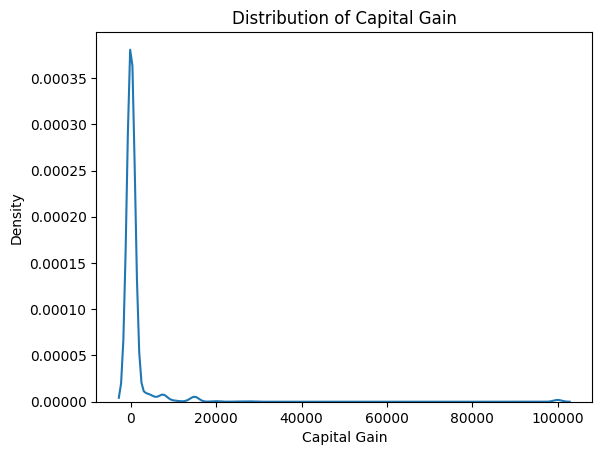

In [ ]:
# Plot the distribution of 'capital-gain'
sns.kdeplot(data=X_train,x='capital_gain')
plt.title("Distribution of Capital Gain")
plt.xlabel("Capital Gain")
plt.show()

###Confirm the extreme skew visually.
The KDE plot shows the most observation are concentrated near Zero, Small numbers of observation are extend to very large values. thats create the long right side tail. so that Confirm the "capital-gain" plot is a positive skewed distribution  and does not a normal distribution.

### Q1.5
Apply Winsorization (clip at 5th–95th percentile) to 'capital-gain' on the training set. Apply the SAME clipping bounds to the test set. Plot before/after KDE plots.


In [ ]:
# TODO:
lower_bound=X_train['capital_gain'].quantile(0.5)
upper_bound=X_train['capital_gain'].quantile(0.95)

X_train_wins=X_train.copy()
X_test_wins=X_test.copy()

# Apply Winsorization (clipping)
X_train_wins['capital_gain']=X_train_wins['capital_gain'].clip(lower=lower_bound,upper=upper_bound)

# Apply the SAME clipping
X_test_wins['capital_gain']=X_test_wins['capital_gain'].clip(lower=lower_bound,upper=upper_bound)

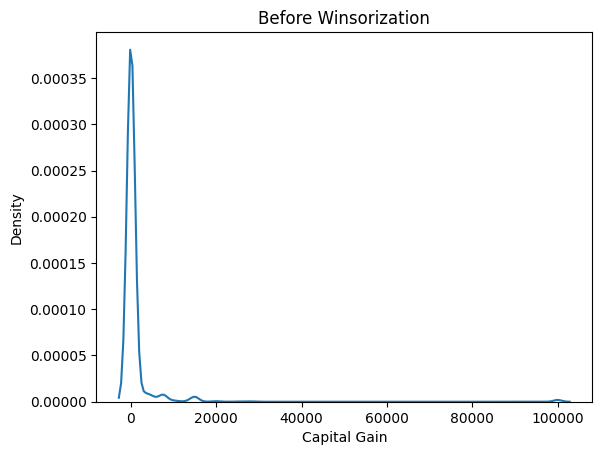

In [ ]:
# Plot before KDE plots.
sns.kdeplot(data=X_train,x='capital_gain')
plt.title("Before Winsorization")
plt.xlabel("Capital Gain")
plt.show()

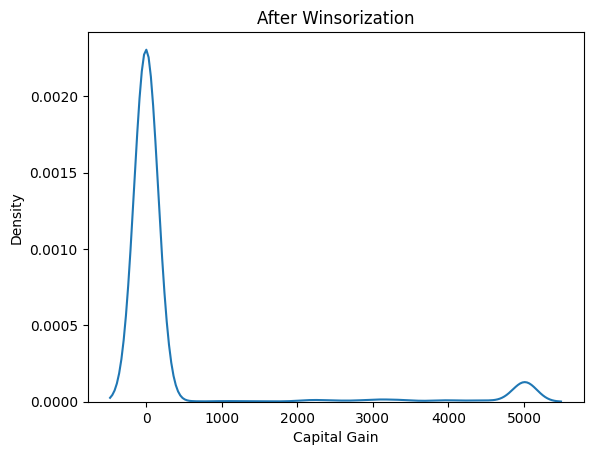

In [ ]:
# Plot after KDE plots.
sns.kdeplot(data=X_train_wins,x='capital_gain')
plt.title("After Winsorization")
plt.xlabel("Capital Gain")
plt.show()

### Q1.6
Apply RobustScaler to 'hours-per-week' and 'capital-gain'. Compare the scaled range with what StandardScaler would have produced. Which handles the outliers better? Justify numerically.


In [ ]:
# TODO:
cols=['hours_per_week','capital_gain']
rs=RobustScaler()
x_robust=X_train.copy()
x_robust[cols]=rs.fit_transform(X_train[cols])

# Apply StandardScale
std=StandardScaler()
x_std=X_train.copy()
x_std[cols]=std.fit_transform(X_train[cols])


In [ ]:
#  Compare the scaled range
print(x_robust[cols].agg(['min','max']),"\n\n")
print(x_std[cols].agg(['min','max']))

     hours_per_week  capital_gain
min            -7.8           0.0
max            11.8       99999.0 


     hours_per_week  capital_gain
min       -3.194296     -0.145715
max        4.753216     13.684139


In [ ]:
# Justification
print("RobustScaler max:")
print(x_robust[cols].max())

print("\nStandardScaler max:")
print(x_std[cols].max())

RobustScaler max:
hours_per_week       11.8
capital_gain      99999.0
dtype: float64

StandardScaler max:
hours_per_week     4.753216
capital_gain      13.684139
dtype: float64


Robust sclaer handles the outliers better. because it is not influenced by extreme values in its calculation (median and IQR-based).

# Q2 — THE CHURNING MACHINE

## THEORY QUESTIONS

### Q2.7
The target column 'Churn' has roughly 73% 'No' and 27% 'Yes'. Explain why this class imbalance matters for a model. If you don't address it, what kind of predictions might the model make?


### Write Your Answer Below
Class imbalance matters because models tend to optimize overall accuracy. the model may predict most customers as non-churners, achieving high accuracy but failing to correctly identify actual churners

### Q2.8
The 'TotalCharges' column is stored as a string (object) despite being numeric. What is the likely reason? What preprocessing step is needed?


### Write Your Answer Below
The TotalCharges column is stored as an object because it contains non-numeric entries such as blank spaces or missing values stored as strings. The required preprocessing step is to convert the column to numeric using pd.to_numeric(errors='coerce')

### Q2.9
From an EDA perspective, what is the difference between a countplot with hue and a grouped bar chart (barplot)? When would you use each for this dataset?


### Write Your Answer Below
1. A countplot shows the number of rows (frequency) in each category.when add hue, it splits those counts by another category.

2. A barplot shows an aggregated statistic (default = mean).

## PRACTICAL QUESTIONS

### Q2.10
Load the dataset. Fix the 'TotalCharges' data type issue. Confirm by checking df.info() before and after.


In [ ]:
# TODO: data info befor missing data type
df_churn=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_churn.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# handle data type issue
df_churn["TotalCharges"]=pd.to_numeric(df_churn["TotalCharges"],errors='coerce')
df_churn["TotalCharges"]=df_churn['TotalCharges'].fillna(df_churn['TotalCharges'].median())
df_churn["TotalCharges"]=df_churn["TotalCharges"].astype('float64')
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Q2.11
Perform full univariate analysis:
(a) For all categorical columns, create countplots;
(b) For all numerical columns, plot histograms with kde=True.
Write at least one business insight per plot.


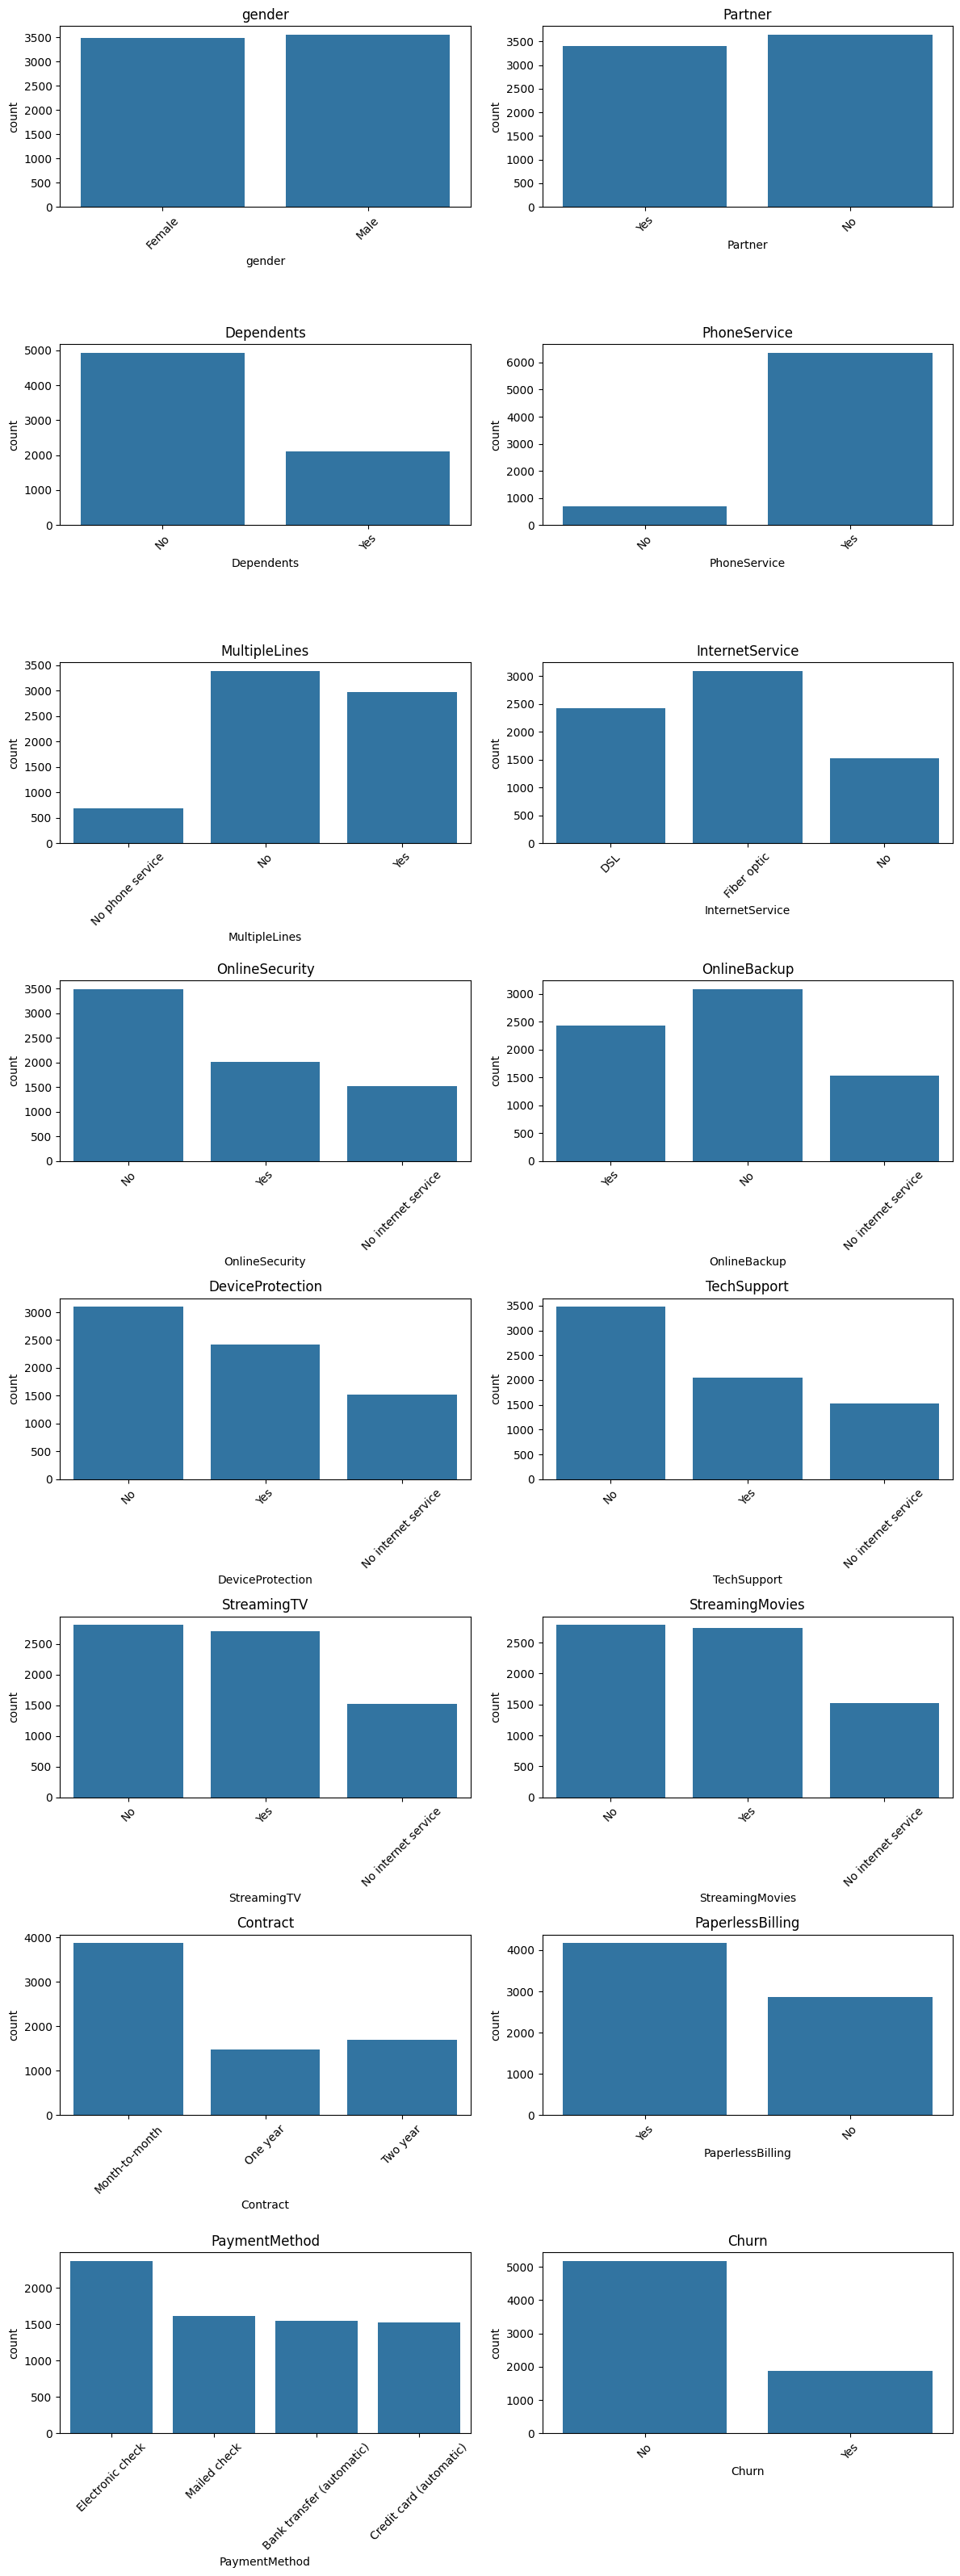

In [ ]:
# all categorical columns, create countplots
cat_cols=df_churn.select_dtypes(include="object").columns
cat_cols = cat_cols.drop("customerID")

n_cols = 2
n_rows = (len(cat_cols) + 1) // 2

plt.figure(figsize=(12, n_rows * 4))

for i, col in enumerate(cat_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(data=df_churn, x=col)
    plt.title(f"{col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

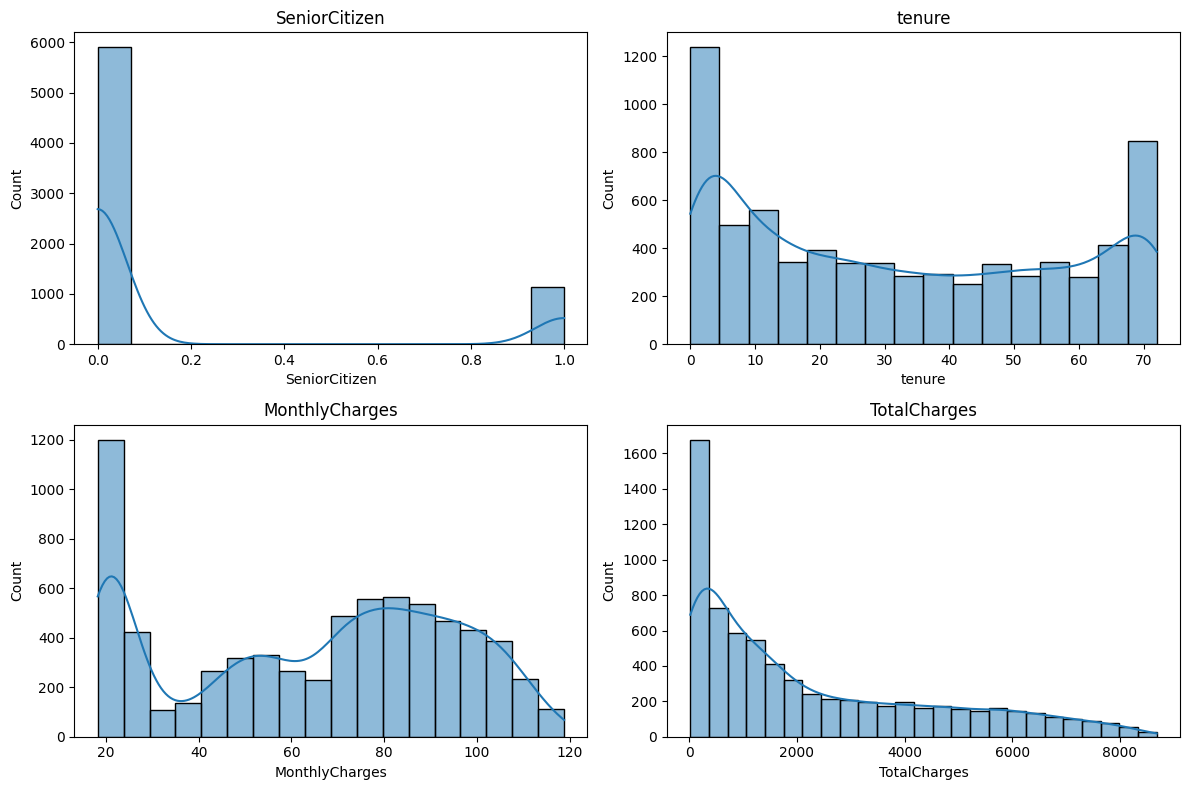

In [ ]:
numeric_cols=df_churn.select_dtypes(include=["int64","float64"]).columns

num_cols = 2
n_rows = (len(numeric_cols) + 1) // 2

plt.figure(figsize=(12, n_rows * 4))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, num_cols, i + 1)
    sns.histplot(data=df_churn, x=col,kde=True)
    plt.title(f"{col}")

plt.tight_layout()
plt.show()

### Q2.12
Perform multivariate analysis:
(a) Create a countplot of 'Contract' vs 'Churn' with hue;
(b) Create a KDE plot of 'tenure' grouped by 'Churn';
Describe two findings that would help a business reduce churn.


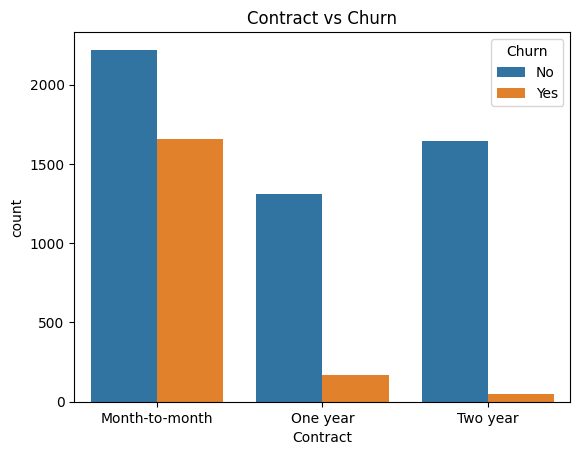

In [ ]:
# Create a countplot of 'Contract' vs 'Churn' with hue
sns.countplot(data=df_churn,x='Contract',hue='Churn')
plt.title("Contract vs Churn")
plt.show()

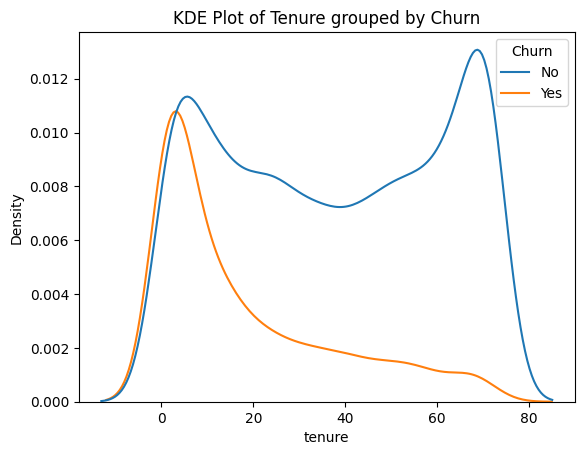

In [ ]:
# Create a KDE plot of 'tenure' grouped by 'Churn'
sns.kdeplot(data=df_churn,x='tenure',hue='Churn')
plt.title("KDE Plot of Tenure grouped by Churn")
plt.show()

# Q3 — Z-SCORES & THE EMPIRICAL RULE IN THE WILD

## THEORY QUESTIONS

### Q3.13
According to the Empirical Rule (68-95-99.7), if BMI is approximately normally distributed with mean=30 and std=6, what percentage of people have BMI above 42?


### Write Your Answer Below
we know that, mean=30, std=6, value=42
so therefore, z-score = (42-30)/6 = 12/6 = 2

Empirical Rule says:

- 68% within ±1σ
- 95% within ±2σ
- 99.7% within ±3σ

Percentage above +2σ (BMI > 42)=2.5%

### Q3.14
You detect that the 'charges' column has a Z-score outlier threshold at |Z| > 3. A student removes ALL rows with |Z| > 3 before the train-test split. Identify two problems with this approach.


### Write Your Answer Below
1. student removes ALL rows with |Z| > 3 before the train-test split causes because information from the test set in influences the decision.

2. Removing all outliers distorts the data distribution and removes potentially valid extreme values.

### Q3.15
Why might the IQR method detect different outliers than the Z-score method on the same column? In which situation is each method preferred?


### Write Your Answer Below
IQR and Z-score detect different outliers because Z-score relies on mean and standard deviation and assumes a normal distribution, while IQR is based on quartiles and is robust to skewed data.

As a result Z-Score is sensitive to extream valuse an work for normal distribution data. on the other hand IQR using skewed and extream outliers distributional data set.

## PRACTICAL QUESTIONS

### Q3.16
Load the dataset. Verify whether 'bmi' follows an approximately normal distribution:
(a) Plot a KDE plot;
(b) Compute skewness


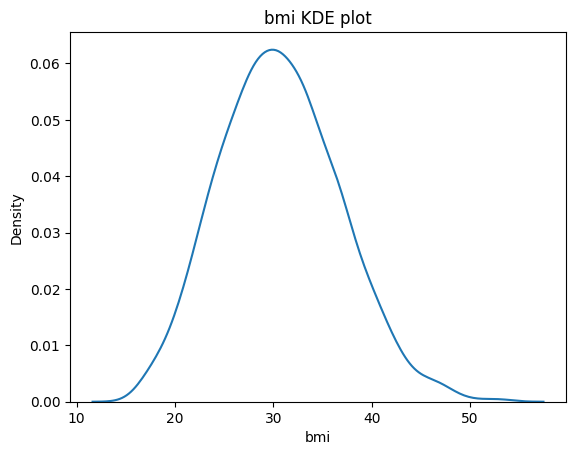

In [ ]:
# TODO:
df_insurance=pd.read_csv("insurance.csv")
sns.kdeplot(data=df_insurance,x=df_insurance['bmi'])
plt.title("bmi KDE plot")
plt.show()

In [ ]:
# Compute skewness
df_insurance['bmi'].skew()

np.float64(0.2840471105987448)

### Q3.17
For the 'charges' column:
(a) Identify outliers using the IQR method
(b) Identify outliers using the Z-score method
(c) Compare how many outliers each method detects.


In [ ]:
# Outlier detects of IQR
Q1=df_insurance['charges'].quantile(0.25)
Q3=df_insurance['charges'].quantile(0.75)
IQR=Q3-Q1
lowar=Q1-1.5*IQR
upper=Q3+1.5*IQR
outlier_detect_IQR=df_insurance[(df_insurance['charges']<lowar)|(df_insurance['charges']>upper)]

In [ ]:
# Outlier detects of Z-Score
charge_mean=df_insurance['charges'].mean()
charge_std=df_insurance['charges'].std()

z_score=(df_insurance['charges']-charge_mean)/charge_std
outlier_detect_Z_score=df_insurance[z_score.abs()>3]

In [ ]:
# Compare how many outliers each method detects.
print("IQR outliers:", len(outlier_detect_IQR))
print("Z-score outliers:", len(outlier_detect_Z_score))

IQR outliers: 139
Z-score outliers: 7


### Q3.18
Create a new feature 'bmi_category' using the WHO thresholds
(Underweight < 18.5, Normal 18.5–24.9, Overweight 25–29.9, Obese >= 30).
Then use a barplot to visualize average 'charges' per BMI category. What pattern
do you see?


In [ ]:
# Create a new feature
def bmi_cat(bmi):
  if bmi<18.5:
    return "Underweight"
  elif bmi <25:
    return "Normal"
  elif bmi<30:
    return "Overweight"
  else:
    return "Obese"

df_insurance['bmi_category']=df_insurance['bmi'].apply(bmi_cat)
df_insurance

,age,sex,bmi,children,smoker,region,charges,bmi_category
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Normal
4,32,male,28.880,0,no,northwest,3866.85520,Overweight
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,Obese
1334,18,female,31.920,0,no,northeast,2205.98080,Obese
1335,18,female,36.850,0,no,southeast,1629.83350,Obese
1336,21,female,25.800,0,no,southwest,2007.94500,Overweight


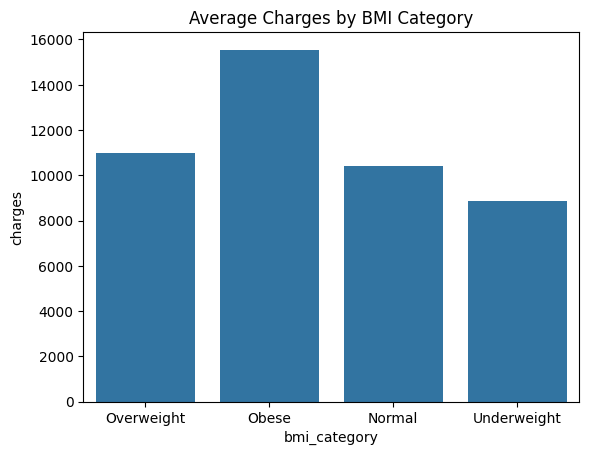

In [ ]:
# Use a barplot to visualize average 'charges' per BMI category.
sns.barplot(data=df_insurance,x='bmi_category',y='charges',errorbar=None)
plt.title("Average Charges by BMI Category")
plt.show()

# Q4 — THE BIG CITY PROBLEM

## THEORY QUESTIONS

### Q4.19
A trip duration of 86,400 seconds (24 hours) exists in this dataset. Is this a
data entry error, a real event, or something else? How would you decide
programmatically AND using domain knowledge?


### Write Your Answer Below

### Q4.20
After removing outliers from the training set, should you also remove
outliers from the test set? Justify your answer carefully — think about what a
test set represents in a real production scenario.


### Write Your Answer Below

No, you should not remove outliers from the test set after removing them from the training set. Because the test set must represent real-world unseen data.

## PRACTICAL QUESTIONS

### Q4.21
Load the dataset (sample 20k rows). Convert 'pickup_datetime' to datetime and extract hour, day-of-week, and month.


In [ ]:
# Load the dataset (sample 20k rows)
df_nyc=pd.read_csv("nyc.csv")
df_nyc.sample(n=20000,random_state=42)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
12506,id0107732,2,2016-01-30 03:16:11,2016-01-30 03:43:46,5,-74.005363,40.717892,-73.963722,40.581936,N,1655.0
6526,id1467994,1,2016-05-12 16:51:19,2016-05-12 17:05:25,1,-73.965515,40.765999,-73.962898,40.764473,N,846.0
8375,id1628638,1,2016-06-24 18:55:41,2016-06-24 19:06:56,1,-74.011948,40.713947,-74.008018,40.705120,N,675.0
34949,id3544514,1,2016-02-19 23:53:28,2016-02-19 23:58:03,1,-73.987038,40.764336,-73.996284,40.759956,N,275.0
35966,id1136862,1,2016-01-26 18:23:32,2016-01-26 18:33:23,2,-73.971954,40.751911,-73.982780,40.757416,N,591.0
...,...,...,...,...,...,...,...,...,...,...,...
21483,id0085964,2,2016-06-12 05:13:39,2016-06-12 05:36:48,5,-73.982101,40.782921,-73.870728,40.773991,N,1389.0
2045,id1877742,2,2016-05-23 19:26:11,2016-05-23 19:41:24,1,-73.993568,40.767410,-73.963478,40.774212,N,913.0
25443,id3435180,1,2016-01-28 16:00:24,2016-01-28 16:07:33,1,-73.981560,40.766052,-73.981155,40.774376,N,429.0
5833,id3584323,1,2016-05-19 11:37:44,2016-05-19 11:59:05,1,-73.976135,40.748661,-74.016953,40.706051,N,1281.0


In [ ]:
# extract hour, day-of-week, and month.
df_nyc['pickup_datetime']=pd.to_datetime(df_nyc['pickup_datetime'])
df_nyc['hour']=df_nyc['pickup_datetime'].dt.hour
df_nyc['day-of-week']=df_nyc['pickup_datetime'].dt.day_of_week
df_nyc['month']=df_nyc['pickup_datetime'].dt.month
df_nyc

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,day-of-week,month
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455.0,17,0,3
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663.0,0,6,6
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124.0,11,1,1
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429.0,19,2,4
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435.0,13,5,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38118,id2138261,1,2016-03-24 20:41:07,2016-03-24 20:48:50,1,-73.983650,40.738228,-73.974907,40.750740,N,463.0,20,3,3
38119,id3498437,1,2016-04-11 10:20:13,2016-04-11 10:50:55,1,-73.981911,40.756802,-73.885284,40.772423,N,1842.0,10,0,4
38120,id1814715,1,2016-05-10 09:17:23,2016-05-10 09:26:45,1,-73.991417,40.750454,-74.004692,40.725559,N,562.0,9,1,5
38121,id1111859,2,2016-02-11 21:49:37,2016-02-11 22:16:06,1,-74.001717,40.724789,-73.949570,40.670071,N,1589.0,21,3,2


### Q4.22
Apply IQR-based outlier detection to 'trip_duration'.
Print:
- number of outliers
- percentage of outliers
Remove them from training set ONLY.


In [ ]:
# Outlier detects of IQR
Q1=df_nyc['trip_duration'].quantile(0.25)
Q3=df_nyc['trip_duration'].quantile(0.75)
IQR=Q3-Q1
lowar=Q1-1.5*IQR
upper=Q3+1.5*IQR
outlier_detect_IQR_nyc=df_nyc[(df_nyc['trip_duration']<lowar)|(df_nyc['trip_duration']>upper)]
print("number of outliers:",len(outlier_detect_IQR_nyc))

number of outliers: 1935


In [ ]:
# percentage of outliers.
percentage_outliers=len(outlier_detect_IQR_nyc)/len(df_nyc)*100
print("percentage_outliers:",percentage_outliers)

percentage_outliers: 5.075676101041366


In [ ]:
# Remove them from training set ONLY
df_nyc_clean=df_nyc[(df_nyc['trip_duration']>=lowar)&(df_nyc['trip_duration']<=upper)]
df_nyc_clean

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,day-of-week,month
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455.0,17,0,3
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663.0,0,6,6
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429.0,19,2,4
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435.0,13,5,3
5,id0801584,2,2016-01-30 22:01:40,2016-01-30 22:09:03,6,-73.982857,40.742195,-73.992081,40.749184,N,443.0,22,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38117,id1393475,1,2016-05-18 09:57:26,2016-05-18 10:12:51,1,-73.980873,40.753326,-73.980385,40.763882,N,925.0,9,2,5
38118,id2138261,1,2016-03-24 20:41:07,2016-03-24 20:48:50,1,-73.983650,40.738228,-73.974907,40.750740,N,463.0,20,3,3
38119,id3498437,1,2016-04-11 10:20:13,2016-04-11 10:50:55,1,-73.981911,40.756802,-73.885284,40.772423,N,1842.0,10,0,4
38120,id1814715,1,2016-05-10 09:17:23,2016-05-10 09:26:45,1,-73.991417,40.750454,-74.004692,40.725559,N,562.0,9,1,5


### Q4.23
Create a scatter plot of pickup_longitude vs pickup_latitude, coloring points by trip_duration.


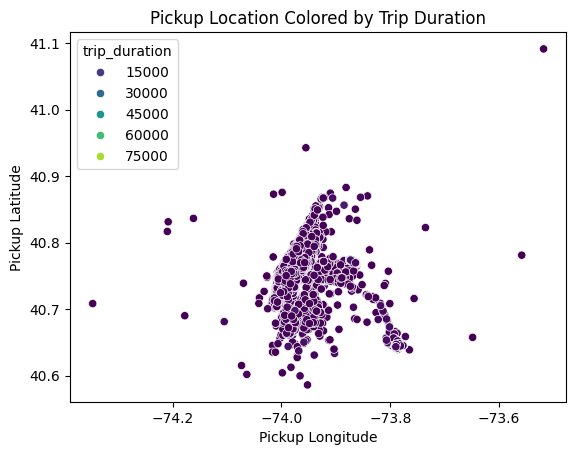

In [ ]:
# TODO:
sns.scatterplot(data=df_nyc,x='pickup_longitude',y='pickup_latitude',hue="trip_duration",palette="viridis")
plt.title("Pickup Location Colored by Trip Duration")
plt.xlabel("Pickup Longitude")
plt.ylabel("Pickup Latitude")
plt.show()

# Q5 — HAPPINESS BY THE NUMBERS

## THEORY QUESTIONS

### Q5.24
The 'Logged GDP per capita' column already has a log transformation applied.
Why might the original GDP per capita have been log-transformed before
inclusion in this report? What distribution property does log-transformation fix?
( Optional : Haven’t covered in the module , you can study it by yourself. We
will cover it if it seems necessary )


### Write Your Answer Below

### Q5.25
Explain conceptually whether you expect these will impact happiness score:
- Social support
- Healthy life expectancy
- Freedom to make life choices


### Write Your Answer Below
Social support, healthy life expectancy, and freedom to make life choices are all expected to have a positive impact on happiness scores.
- Social support improves emotional well-being through relationships.
- healthy life expectancy reflects physical health.
- freedom of choice enhances life satisfaction.

### Q5.26
A student concludes from a scatterplot that 'high GDP causes high happiness'. Critique this conclusion.


### Write Your Answer Below
The conclusion is wrong because scatterplots show correlation, not causation.
 - other factors (social support, health, freedom) may influence both.
 - it can be reversed (happiness → productivity → GDP)

So i can say “GDP is associated with happiness,” not that it causes it.

In [ ]:
# Load data set
df_happy=pd.read_csv('world-happiness-report-2021.csv')
df_happy

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.000,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.700,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.400,0.919,0.025,0.292,2.43,1.566,1.079,0.816,0.653,0.204,0.413,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.000,0.955,0.160,0.673,2.43,1.482,1.172,0.772,0.698,0.293,0.170,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.400,0.913,0.175,0.338,2.43,1.501,1.079,0.753,0.647,0.302,0.384,2.798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,Lesotho,Sub-Saharan Africa,3.512,0.120,3.748,3.276,7.926,0.787,48.700,0.715,-0.131,0.915,2.43,0.451,0.731,0.007,0.405,0.103,0.015,1.800
145,Botswana,Sub-Saharan Africa,3.467,0.074,3.611,3.322,9.782,0.784,59.269,0.824,-0.246,0.801,2.43,1.099,0.724,0.340,0.539,0.027,0.088,0.648
146,Rwanda,Sub-Saharan Africa,3.415,0.068,3.548,3.282,7.676,0.552,61.400,0.897,0.061,0.167,2.43,0.364,0.202,0.407,0.627,0.227,0.493,1.095
147,Zimbabwe,Sub-Saharan Africa,3.145,0.058,3.259,3.030,7.943,0.750,56.201,0.677,-0.047,0.821,2.43,0.457,0.649,0.243,0.359,0.157,0.075,1.205


## PRACTICAL QUESTIONS

### Q5.27
Identify the top 10 and bottom 10 happiest countries. Create a horizontal bar chart.


In [ ]:
# top 10 happiest countries
top_10=df_happy.nlargest(10,'Ladder score')
bottom_10=df_happy.nsmallest(10,'Ladder score')

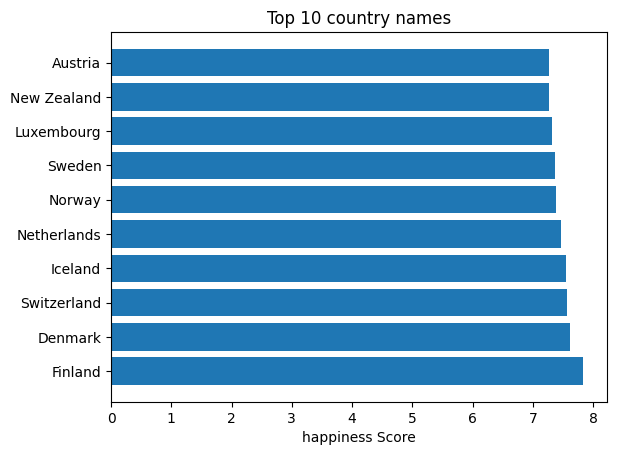

In [ ]:
# Create a horizontal bar chart.
plt.barh(top_10['Country name'],top_10['Ladder score'])
plt.title("Top 10 country names")
plt.xlabel("happiness Score")
plt.show()

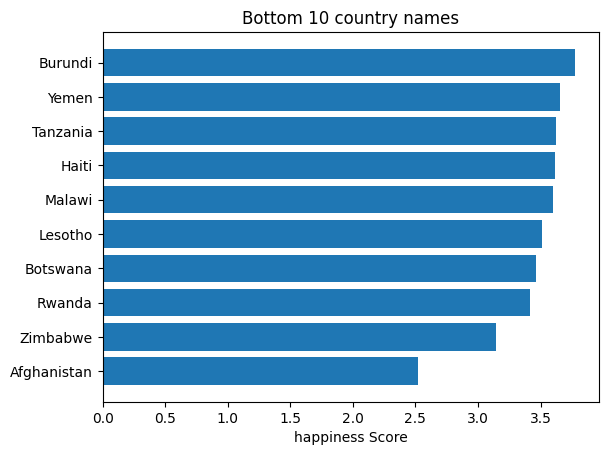

In [ ]:
plt.barh(bottom_10['Country name'],bottom_10['Ladder score'])
plt.title("Bottom 10 country names")
plt.xlabel("happiness Score")
plt.show()

### Q5.28
Create a scatterplot of 'Logged GDP per capita' vs 'Ladder score'. Add a
regression line using sns.regplot().


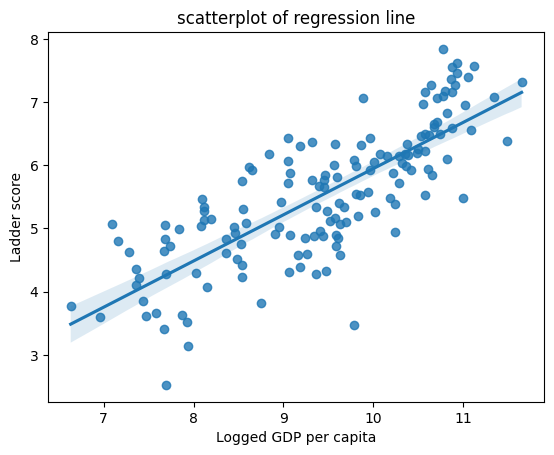

In [ ]:
# TODO:
sns.regplot(data=df_happy,x='Logged GDP per capita',y='Ladder score')
plt.title("scatterplot of regression line")
plt.show()

### Q5.29
Perform regional analysis: group by 'Regional indicator' and compute the
mean of all numeric columns. Visualize mean happiness by region using a barplot
sorted by score. Which region has the highest variance in happiness? Use a boxplot
to verify.


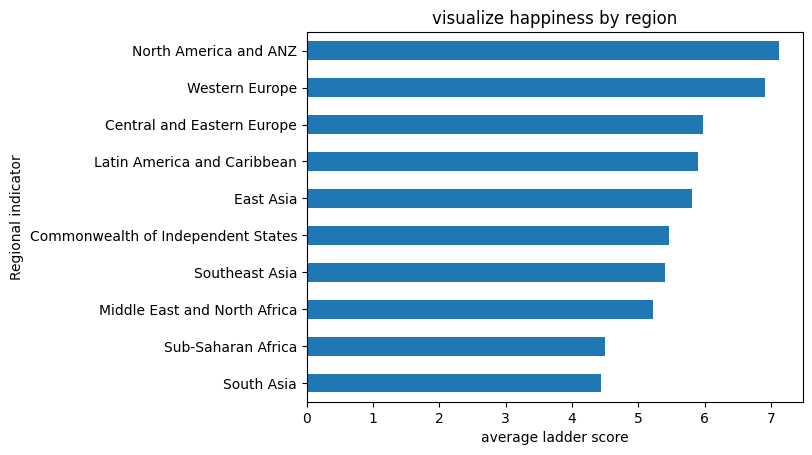

In [ ]:
# TODO:
regional_means=df_happy.groupby('Regional indicator').mean(numeric_only=True)
sorted_region=regional_means['Ladder score'].sort_values(ascending=True)
sorted_region.plot(kind='barh')
plt.title("visualize happiness by region")
plt.xlabel("average ladder score")
plt.show()

In [ ]:
# identify highest variance region
region_varience=df_happy.groupby('Regional indicator')['Ladder score'].var().sort_values(ascending=False)
print("highest variance region:",region_varience.idxmax())
print("\nhighest variance region Value:",region_varience.max())

highest variance region: Middle East and North Africa

highest variance region Value: 0.9985189411764702


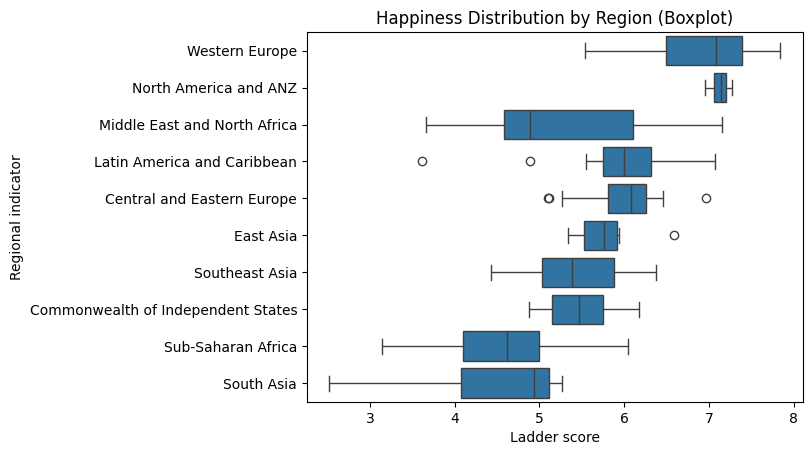

In [ ]:
# boxplot
sns.boxplot(data=df_happy,x='Ladder score',y='Regional indicator')
plt.title('Happiness Distribution by Region (Boxplot)')
plt.show()

# SURPRISE BONUS CHALLENGE

Pick ANY one of the 5 datasets above. Build a complete, end-to-end sklearn
ColumnTransformer that:
- Handles missing values with the correct strategy for each column type
- Encodes all categorical features appropriately for the model
- Applies the right scaler (Standard vs. Robust — justify your choice)
- Handles outliers using either Zscore , IQR clipping or Winsorization (before
the pipeline)


In [ ]:
# handle outlier befor pipeline
col=['age','capital_gain','capital_loss',	'hours_per_week']
for i in col:
  Q1=df_adult[i].quantile(0.25)
  Q3=df_adult[i].quantile(0.75)
  IQR=Q3-Q1
  lowar_adult=Q1-1.5*IQR
  upper_adult=Q3+1.5*IQR
  df_adult[i]=df_adult[i].clip(lowar_adult,upper_adult)

In [ ]:
# separate the column types
num_feature=list(df_adult.select_dtypes(include=["int64","float64"]).columns)
cat_feature=list(df_adult.select_dtypes(include=["object"]).columns)
cat_feature=[col for col in cat_feature if col !='income']

In [ ]:
# Handles missing values with the correct strategy for each column type
num_pipeline=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])
cat_pipeline=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

In [ ]:
# Column transform
col_transform=ColumnTransformer(transformers=[
    ('num',num_pipeline,num_feature),
    ('cat',cat_pipeline,cat_feature)
])
x_transform=col_transform.fit_transform(df_adult)

In [ ]:
X_df = pd.DataFrame(x_transform)
X_df.shape

(32561, 105)